## Homework: Multilingual Embedding-based Machine Translation (6 points)

**In this homework** **<font color='red'>YOU</font>** will make a machine translation system without using parallel corpora, alignment, attention, 100500-depth super-cool recurrent neural networks and all that kind of superstuff.

But even without parallel corpora, this system can be good enough (hopefully). 

For our system we choose two kindred Slavic languages: Ukrainian and Russian. 

### Feel the difference!

(_синій кіт_ vs. _синій кит_)

![blue_cat_blue_whale.png](https://github.com/yandexdataschool/nlp_course/raw/master/resources/blue_cat_blue_whale.png)

### Fragment of the Swadesh list for some Slavic languages

The Swadesh list is a lexicostatistical tool. It's named after American linguist Morris Swadesh and contains basic lexis. These lists are used to define subgroupings of languages and their relatedness.

So we can see some kind of word invariance for different Slavic languages.


| Russian         | Belorussian              | Ukrainian               | Polish             | Czech                         | Bulgarian            |
|-----------------|--------------------------|-------------------------|--------------------|-------------------------------|-----------------------|
| женщина         | жанчына, кабета, баба    | жінка                   | kobieta            | žena                          | жена                  |
| мужчина         | мужчына                  | чоловік, мужчина        | mężczyzna          | muž                           | мъж                   |
| человек         | чалавек                  | людина, чоловік         | człowiek           | člověk                        | човек                 |
| ребёнок, дитя   | дзіця, дзіцёнак, немаўля | дитина, дитя            | dziecko            | dítě                          | дете                  |
| жена            | жонка                    | дружина, жінка          | żona               | žena, manželka, choť          | съпруга, жена         |
| муж             | муж, гаспадар            | чоловiк, муж            | mąż                | muž, manžel, choť             | съпруг, мъж           |
| мать, мама      | маці, матка              | мати, матір, неня, мама | matka              | matka, máma, 'стар.' mateř    | майка                 |
| отец, тятя      | бацька, тата             | батько, тато, татусь    | ojciec             | otec                          | баща, татко           |
| много           | шмат, багата             | багато                  | wiele              | mnoho, hodně                  | много                 |
| несколько       | некалькі, колькі         | декілька, кілька        | kilka              | několik, pár, trocha          | няколко               |
| другой, иной    | іншы                     | інший                   | inny               | druhý, jiný                   | друг                  |
| зверь, животное | жывёла, звер, істота     | тварина, звір           | zwierzę            | zvíře                         | животно               |
| рыба            | рыба                     | риба                    | ryba               | ryba                          | риба                  |
| птица           | птушка                   | птах, птиця             | ptak               | pták                          | птица                 |
| собака, пёс     | сабака                   | собака, пес             | pies               | pes                           | куче, пес             |
| вошь            | вош                      | воша                    | wesz               | veš                           | въшка                 |
| змея, гад       | змяя                     | змія, гад               | wąż                | had                           | змия                  |
| червь, червяк   | чарвяк                   | хробак, черв'як         | robak              | červ                          | червей                |
| дерево          | дрэва                    | дерево                  | drzewo             | strom, dřevo                  | дърво                 |
| лес             | лес                      | ліс                     | las                | les                           | гора, лес             |
| палка           | кій, палка               | палиця                  | patyk, pręt, pałka | hůl, klacek, prut, kůl, pálka | палка, пръчка, бастун |

But the context distribution of these languages demonstrates even more invariance. And we can use this fact for our purposes.

## Data

In [1]:
import gensim
import numpy as np
from gensim.models import KeyedVectors

Download embeddings here:
* [cc.uk.300.vec.zip](https://yadi.sk/d/9CAeNsJiInoyUA)
* [cc.ru.300.vec.zip](https://yadi.sk/d/3yG0-M4M8fypeQ)

Load embeddings for Ukrainian and Russian.

In [ ]:
# uk_emb = KeyedVectors.load_word2vec_format(r"E:\07_models\cc.uk.300.vec")

In [ ]:
# ru_emb = KeyedVectors.load_word2vec_format(r"E:\07_models\cc.ru.300.vec")

In [5]:
# Chỉ load 200,000 từ phổ biến nhất thay vì toàn bộ
ru_emb = KeyedVectors.load_word2vec_format(r"E:\07_models\cc.ru.300.vec", limit=200000)
uk_emb = KeyedVectors.load_word2vec_format(r"E:\07_models\cc.uk.300.vec", limit=200000)

In [6]:
ru_emb.most_similar([ru_emb["август"]], topn=10)

[('август', 1.0000001192092896),
 ('июль', 0.9383152723312378),
 ('сентябрь', 0.9240029454231262),
 ('июнь', 0.9222574830055237),
 ('октябрь', 0.9095539450645447),
 ('ноябрь', 0.8930036425590515),
 ('апрель', 0.8729087114334106),
 ('декабрь', 0.8652557730674744),
 ('март', 0.8545795679092407),
 ('февраль', 0.8401415944099426)]

In [7]:
uk_emb.most_similar([uk_emb["серпень"]])

[('серпень', 0.9999998807907104),
 ('липень', 0.9096441268920898),
 ('вересень', 0.9016969203948975),
 ('червень', 0.8992518782615662),
 ('жовтень', 0.8810408115386963),
 ('листопад', 0.8787633180618286),
 ('квітень', 0.8592804670333862),
 ('грудень', 0.8586863279342651),
 ('травень', 0.840811014175415),
 ('лютий', 0.8256431221961975)]

In [8]:
ru_emb.most_similar([uk_emb["серпень"]])

[('deteydlya', 0.230317160487175),
 ('пресечении', 0.22632381319999695),
 ('одностороннего', 0.22608886659145355),
 ('подход', 0.2230587750673294),
 ('конструктивное', 0.21656130254268646),
 ('подхода', 0.2142382562160492),
 ('Семёныч', 0.2130262851715088),
 ('Предотвращение', 0.21292470395565033),
 ('аспектах', 0.21134458482265472),
 ('двустороннего', 0.21055522561073303)]

Load small dictionaries for corresponding word pairs as training set and test set.

In [12]:
def load_word_pairs(filename):
    uk_ru_pairs = []
    uk_vectors = []
    ru_vectors = []
    with open(filename, "r", encoding="utf-8") as inpf:
        for line in inpf:
            uk, ru = line.rstrip().split("\t")
            if uk not in uk_emb or ru not in ru_emb:
                continue
            uk_ru_pairs.append((uk, ru))
            uk_vectors.append(uk_emb[uk])
            ru_vectors.append(ru_emb[ru])
    return uk_ru_pairs, np.array(uk_vectors), np.array(ru_vectors)

In [10]:
uk_ru_train, X_train, Y_train = load_word_pairs("ukr_rus.train.txt")

In [11]:
uk_ru_test, X_test, Y_test = load_word_pairs("ukr_rus.test.txt")

## Embedding space mapping

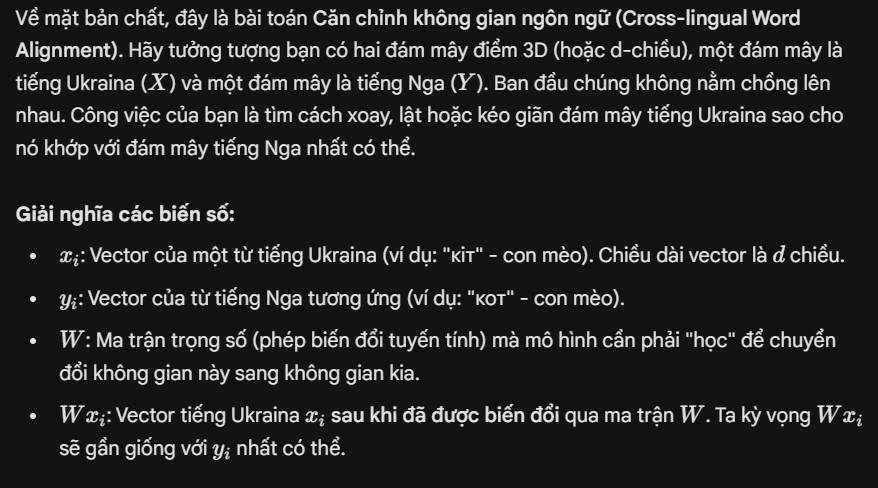

Let $x_i \in \mathrm{R}^d$ be the distributed representation of word $i$ in the source language, and $y_i \in \mathrm{R}^d$ is the vector representation of its translation. Our purpose is to learn such a linear transform $W$ that minimizes the Euclidean distance between $Wx_i$ and $y_i$ for some subset of word embeddings. Thus we can formulate the so-called Procrustes problem:

$$W^*= \arg\min_W \sum_{i=1}^n||Wx_i - y_i||_2$$
or
$$W^*= \arg\min_W ||WX - Y||_F$$

where $||*||_F$ is the Frobenius norm.

In Greek mythology, Procrustes or "the stretcher" was a rogue smith and bandit from Attica who attacked people by stretching them or cutting off their legs, so as to force them to fit the size of an iron bed. We do the same bad things with the source embedding space. Our Procrustean bed is the target embedding space.

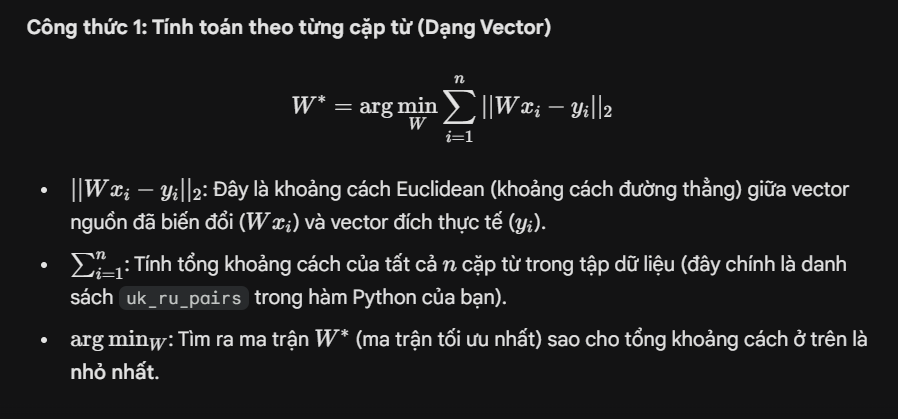

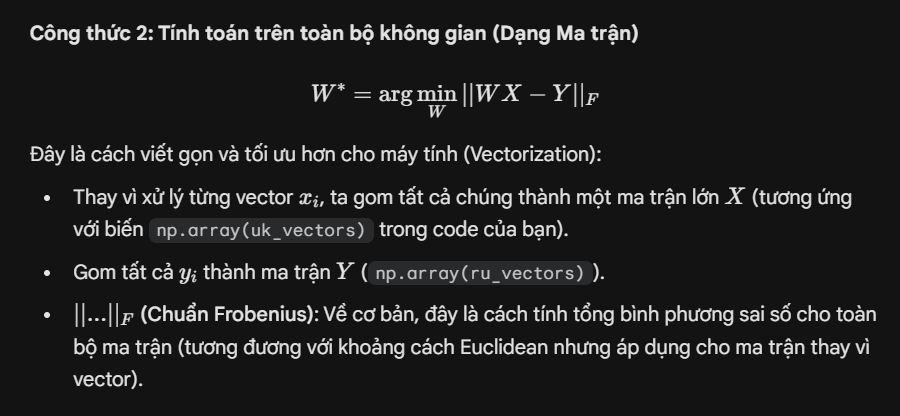

![embedding_mapping.png](https://github.com/yandexdataschool/nlp_course/raw/master/resources/embedding_mapping.png)

![procrustes.png](https://github.com/yandexdataschool/nlp_course/raw/master/resources/procrustes.png)

But wait... $W^*= \arg\min_W \sum_{i=1}^n||Wx_i - y_i||_2$ looks like simple multiple linear regression (without intercept fit). So let's code.

In [13]:
from sklearn.linear_model import LinearRegression

# YOUR CODE HERE
# Example: mapping = LinearRegression(fit_intercept=False).fit(X_train, Y_train)

# 1. Huấn luyện mô hình để tìm ma trận biến đổi W (mapping)
# Giả sử X_train là uk_vectors và Y_train là ru_vectors đã được load từ hàm load_word_pairs
mapping = LinearRegression(fit_intercept=False).fit(X_train, Y_train)

# 2. Lấy vector của từ "серпень" (tháng 8 trong tiếng Ukraina) và định dạng lại thành ma trận 2D
august_uk_vec = uk_emb["серпень"].reshape(1, -1)

# 3. Sử dụng mô hình đã huấn luyện để dự đoán (ánh xạ) vector này sang không gian tiếng Nga
august_ru_predicted = mapping.predict(august_uk_vec)

# 4. Tìm các từ tiếng Nga có vector thực tế nằm gần với vector dự đoán nhất
similar_words = ru_emb.most_similar(august_ru_predicted)

# In kết quả ra để kiểm tra
print(similar_words)

[('апрель', 0.8580324053764343), ('июнь', 0.8481696844100952), ('сентябрь', 0.8453500866889954), ('март', 0.8431740403175354), ('октябрь', 0.8401656746864319), ('февраль', 0.8388595581054688), ('ноябрь', 0.8364996314048767), ('июль', 0.8311647176742554), ('август', 0.8221889734268188), ('декабрь', 0.8134949207305908)]


Let's take a look at neighbors of the vector of word _"серпень"_ (_"август"_ in Russian) after linear transform.

In [14]:
august = mapping.predict(uk_emb["серпень"].reshape(1, -1))
ru_emb.most_similar(august)

[('апрель', 0.8580324053764343),
 ('июнь', 0.8481696844100952),
 ('сентябрь', 0.8453500866889954),
 ('март', 0.8431740403175354),
 ('октябрь', 0.8401656746864319),
 ('февраль', 0.8388595581054688),
 ('ноябрь', 0.8364996314048767),
 ('июль', 0.8311647176742554),
 ('август', 0.8221889734268188),
 ('декабрь', 0.8134949207305908)]

We can see that the neighborhood of this embedding consists of different months, but the right variant is in ninth place.

As a quality measure we will use precision top-1, top-5 and top-10 (for each transformed Ukrainian embedding we count how many correct target pairs are found in the top N nearest neighbors in Russian embedding space).

In [15]:
def precision(pairs, mapped_vectors, topn=1):
    """
    :args:
        pairs = list of correct word pairs [(uk_word_0, ru_word_0), ...]
        mapped_vectors = list of embeddings after mapping from source embedding space to destination embedding space
        topn = the number of nearest neighbors in destination embedding space to choose from
    :returns:
        precision_val, float number, total number of words for which we can find correct translation in top K.
    """
    assert len(pairs) == len(mapped_vectors)
    num_matches = 0
    for i, (_, ru) in enumerate(pairs):
        # Lấy vector tiếng Ukraina đã được ánh xạ (predict) sang không gian tiếng Nga
        mapped_vec = mapped_vectors[i]
        
        # Tìm 'topn' từ tiếng Nga gần nhất với vector này.
        # Lưu ý: Với thư viện như Gensim, ta thường truyền tham số positive=[vector]
        similar_items = ru_emb.most_similar(positive=[mapped_vec], topn=topn)
        
        # Kết quả của most_similar thường là một list các tuple: [(word1, score1), (word2, score2), ...]
        # Ta dùng List Comprehension để tách lấy danh sách các từ, bỏ qua điểm số
        predicted_words = [word for word, score in similar_items]
        
        # Kiểm tra xem từ tiếng Nga đúng ('ru') có nằm trong danh sách dự đoán không
        if ru in predicted_words:
            num_matches += 1
    precision_val = num_matches / len(pairs)
    return precision_val


In [16]:
assert precision([("серпень", "август")], august, topn=5) == 0.0
assert precision([("серпень", "август")], august, topn=9) == 1.0
assert precision([("серпень", "август")], august, topn=10) == 1.0

In [17]:
assert precision(uk_ru_test, X_test) == 0.0
assert precision(uk_ru_test, Y_test) == 1.0

In [18]:
precision_top1 = precision(uk_ru_test, mapping.predict(X_test), 1)
precision_top5 = precision(uk_ru_test, mapping.predict(X_test), 5)

assert precision_top1 >= 0.635
assert precision_top5 >= 0.813

## Making it better (orthogonal Procrustean problem)

It can be shown (see [original paper](https://arxiv.org/pdf/1710.04087)) that a self-consistent linear mapping between semantic spaces should be orthogonal. 
We can restrict the transform $W$ to be orthogonal. Then we will solve the next problem:

$$W^*= \arg\min_W ||WX - Y||_F \text{, where: } W^TW = I$$

$$I \text{ - identity matrix}$$

Instead of making yet another regression problem, we can find the optimal orthogonal transformation using singular value decomposition. It turns out that the optimal transformation $W^*$ can be expressed via SVD components:
$$X^TY=U\Sigma V^T\text{, singular value decomposition}$$
$$W^*=UV^T$$

Ở bước trước (khi dùng LinearRegression), chúng ta đã cho phép ma trận $W$ biến đổi tự do. Điều này đôi khi làm không gian vector bị biến dạng quá mức (tưởng tượng "chiếc giường sắt" làm gãy xương nạn nhân thay vì chỉ kéo giãn). Bằng cách ép $W$ phải là một ma trận trực giao ($W^TW = I$), chúng ta đang nói với mô hình rằng: "Bạn chỉ được phép xoay (rotate) và lật (reflect) không gian từ vựng, tuyệt đối không được bóp méo khoảng cách tương đối giữa các từ với nhau". Cách giải này (dùng SVD) còn được gọi là thuật toán Orthogonal Procrustes, chính xác và hiệu quả hơn rất nhiều!

Nhưng về mặt hình học và trực quan, ma trận trực giao có một sức mạnh vô cùng đặc biệt: Nó chỉ thực hiện phép XOAY (Rotation) hoặc LẬT (Reflection) không gian, mà TUYỆT ĐỐI KHÔNG làm thay đổi kích thước hay hình dáng của vật thể.

Tính chất "vàng" của ma trận trực giao:

Bảo toàn khoảng cách: Khoảng cách giữa điểm A và điểm B trước khi biến đổi bằng đúng khoảng cách giữa chúng sau khi biến đổi.

Bảo toàn góc: Góc giữa hai vector không bị thay đổi.

In [19]:
def learn_transform(X_train, Y_train):
    """ 
    :returns: W* : float matrix[emb_dim x emb_dim] as defined in formulae above
    """
    # Bước 1: Tính tích của ma trận X chuyển vị (X^T) và ma trận Y
    # Tương đương công thức: M = X^T * Y
    M = np.dot(X_train.T, Y_train)
    
    # Bước 2: Thực hiện phân tích SVD trên ma trận M vừa tìm được
    # Hàm np.linalg.svd sẽ trả về 3 thành phần: U, S (tức là Sigma), và V^T
    U, S, Vt = np.linalg.svd(M)
    
    # Bước 3: Tính ma trận trực giao tối ưu W*
    # Tương đương công thức: W* = U * V^T
    W_star = np.dot(U, Vt)
    
    return W_star

In [ ]:
W = learn_transform(X_train, Y_train) # là không gian biến đổi do chỉ xoay

In [21]:
ru_emb.most_similar([np.matmul(uk_emb["серпень"], W)]) # nhân với không gian để chuyển thành từ trong không gian target sau đó lấy độ tương đồng

[('апрель', 0.8264221549034119),
 ('сентябрь', 0.8074066042900085),
 ('июнь', 0.8053567409515381),
 ('март', 0.8025138974189758),
 ('октябрь', 0.8002161383628845),
 ('ноябрь', 0.7975247502326965),
 ('август', 0.796047568321228),
 ('июль', 0.795419454574585),
 ('февраль', 0.7939949035644531),
 ('декабрь', 0.7711036205291748)]

In [22]:
assert precision(uk_ru_test, np.matmul(X_test, W)) >= 0.653
assert precision(uk_ru_test, np.matmul(X_test, W), 5) >= 0.824

## UK-RU Translator

Now we are ready to make a simple word-based translator: for each word in the source language in shared embedding space we find the nearest in the target language.


In [23]:
with open("fairy_tale.txt", "r", encoding="utf-8") as inpf:
    uk_sentences = [line.rstrip().lower() for line in inpf]

In [29]:
import numpy as np

def translate(sentence):
    """
    :args:
        sentence - sentence in Ukrainian (str)
    :returns:
        translation - sentence in Russian (str)
    """
    words = sentence.split()
    translated_words = []
    
    for word in words:
        # Kiểm tra: Từ phải nằm trong từ điển VÀ phải là chữ cái (để chặn số/dấu câu)
        # Lưu ý: Tuỳ thuộc vào ngôn ngữ mà hàm isalpha() có thể bỏ qua từ có chứa dấu nháy đơn. 
        # Nếu bộ test có từ chứa dấu nháy (như зв'язок), bạn có thể dùng len(word) > 1 để thay thế isalpha()
        if word in uk_emb and word.isalpha():
            uk_vec = uk_emb[word]
            
            # Nếu dùng ma trận SVD: np.dot(uk_vec, W)
            # Nếu dùng Linear Regression: np.dot(uk_vec, W.T)
            mapped_vec = np.dot(uk_vec, W) 
            
            # Thêm từ khoá positive= để tương thích tốt nhất với mọi phiên bản Gensim
            similar_words = ru_emb.most_similar(positive=[mapped_vec], topn=1)
            
            best_ru_word = similar_words[0][0]
            translated_words.append(best_ru_word)
        else:
            # Fallback: Giữ nguyên từ gốc nếu nó là số, dấu câu, hoặc không có trong từ điển
            translated_words.append(word)
            
    translation = " ".join(translated_words)
    return translation

In [30]:
assert translate(".") == "."
assert translate("1 , 3") == "1 , 3"
assert translate("кіт зловив мишу") == "кот поймал мышку"

In [31]:
for sentence in uk_sentences:
    print("src: {}\ndst: {}\n".format(sentence, translate(sentence)))

src: лисичка - сестричка і вовк - панібрат
dst: лиса - сестричка и волк - панібрат

src: як була собі лисичка та зробила хатку, та й живе. а це приходять холоди. от лисичка замерзла та й побігла в село вогню добувать, щоб витопити. прибігає до одної баби та й каже:
dst: как была себе лиса и сделала хатку, и и живе. а оно приходят холоди. из лиса замерзла и и побежала во село огня добувать, чтобы витопити. прибігає к одной бабы и и каже:

src: — здорові були, бабусю! з неділею... позичте мені огню, я вам одслужу.
dst: — здоровые були, бабусю! со неділею... позичте мне огню, мной тебе одслужу.

src: — добре, — каже, — лисичко - сестричко. сідай погрійся трохи, поки я пиріжечки повибираю з печі!
dst: — добре, — каже, — лисичко - сестричко. садись погрійся трохи, пока мной пиріжечки повибираю со печі!

src: а баба макові пиріжки пекла. от баба вибирає пиріжки та на столі кладе, щоб прохололи; а лисичка підгляділа та за пиріг, та з хати... виїла мачок із середини, а туди напхала сміттячка, 

Not so bad, right? We can easily improve translation using a language model and not one but several nearest neighbors in shared embedding space. But that's for next time.

## Would you like to learn more?

### Articles:
* [Exploiting Similarities among Languages for Machine Translation](https://arxiv.org/pdf/1309.4168)  - entry point for multilingual embedding studies by Tomas Mikolov (the author of W2V)
* [Offline bilingual word vectors, orthogonal transformations and the inverted softmax](https://arxiv.org/pdf/1702.03859) - orthogonal transform for unsupervised MT
* [Word Translation Without Parallel Data](https://arxiv.org/pdf/1710.04087)
* [Loss in Translation: Learning Bilingual Word Mapping with a Retrieval Criterion](https://arxiv.org/pdf/1804.07745)
* [Unsupervised Alignment of Embeddings with Wasserstein Procrustes](https://arxiv.org/pdf/1805.11222)

### Repos (with ready-to-use multilingual embeddings):
* https://github.com/facebookresearch/MUSE

* https://github.com/Babylonpartners/fastText_multilingual -